**Import Libraries**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from codecarbon import EmissionsTracker
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve



**Read Data**

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train['user_id'] = train['user_id'].str[1:].astype(int)
test['user_id'] = test['user_id'].str[1:].astype(int)



**Drop Null Values and Duplicates**

In [3]:
train = train.dropna()
test = test.dropna()

train = train.drop_duplicates()
test = test.drop_duplicates()



**Balance the Dataset**

In [4]:
ones = train[train['label'] == 1]
zeros = train[train['label'] == 0]

zeros = zeros.sample(n=len(ones), random_state=42)
train = pd.concat([ones, zeros], axis=0).reset_index(drop=True)



**Vectorize the Text Data**

In [ ]:
tracker = EmissionsTracker()
tracker.start()
vectorizer = TfidfVectorizer(max_features=5000)
text_features = vectorizer.fit_transform(train['text'])
text_features_test = vectorizer.transform(test['text'])


X_train = hstack([train[['user_id']], text_features])
X_test = hstack([test[['user_id']], text_features_test])
y_train = train['label']
y_test = test['label']


[codecarbon INFO @ 15:22:15] [setup] RAM Tracking...
[codecarbon INFO @ 15:22:15] [setup] CPU Tracking...
[codecarbon WARNING @ 15:22:15] No CPU tracking mode found. Falling back on CPU constant mode. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 15:22:17] CPU Model on constant consumption mode: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon INFO @ 15:22:17] [setup] GPU Tracking...
[codecarbon INFO @ 15:22:17] No GPU found.
[codecarbon INFO @ 15:22:17] >>> Tracker's metadata:
[codecarbon INFO @ 15:22:17]   Platform system: Windows-10-10.0.22631-SP0
[codecarbon INFO @ 15:22:17]   Python version: 3.11.2
[codecarbon INFO @ 15:22:17]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 15:22:17]   Available RAM : 13.866 GB
[codecarbon INFO @ 15:22:17]   CPU count: 12
[codecarbon INFO @ 15:22:17]   CPU model: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon INFO @ 15:22:17]   GPU count: None
[codecarbon INFO @ 15:22:17]   GPU model: None
[codeca

[codecarbon INFO @ 15:29:17] Energy consumed for RAM : 0.000585 kWh. RAM Power : 5.199734687805176 W
[codecarbon INFO @ 15:29:17] Energy consumed for all CPUs : 0.002568 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 15:29:17] 0.003153 kWh of electricity used since the beginning.
[codecarbon INFO @ 15:29:32] Energy consumed for RAM : 0.000607 kWh. RAM Power : 5.199734687805176 W
[codecarbon INFO @ 15:29:32] Energy consumed for all CPUs : 0.002662 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 15:29:32] 0.003268 kWh of electricity used since the beginning.
[codecarbon INFO @ 15:29:47] Energy consumed for RAM : 0.000628 kWh. RAM Power : 5.199734687805176 W
[codecarbon INFO @ 15:29:47] Energy consumed for all CPUs : 0.002755 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 15:29:47] 0.003384 kWh of electricity used since the beginning.
[codecarbon INFO @ 15:30:02] Energy consumed for RAM : 0.000650 kWh. RAM Power : 5.199734687805176 W
[codecarbon INFO @ 15:30:02] Energy consumed for a

**Train the Model**

In [ ]:

lr = LogisticRegression(max_iter=1000, random_state=42, verbose=2, solver='liblinear')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
emissions = tracker.stop()
print(f"Emissions: {emissions} kg CO2eq")




# emissions = ≈ 93.59 mg CO₂ 
# electricity =  0.003111 kWh About 1/3 of a phone charge


[LibLinear]

[codecarbon INFO @ 15:30:17] Energy consumed for RAM : 0.000672 kWh. RAM Power : 5.199734687805176 W
[codecarbon INFO @ 15:30:17] Energy consumed for all CPUs : 0.002943 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 15:30:17] 0.003615 kWh of electricity used since the beginning.
[codecarbon INFO @ 15:30:32] Energy consumed for RAM : 0.000693 kWh. RAM Power : 5.199734687805176 W
[codecarbon INFO @ 15:30:32] Energy consumed for all CPUs : 0.003037 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 15:30:32] 0.003730 kWh of electricity used since the beginning.
[codecarbon INFO @ 15:30:32] 0.000229 g.CO2eq/s mean an estimation of 7.237433699304515 kg.CO2eq/year
[codecarbon INFO @ 15:30:47] Energy consumed for RAM : 0.000715 kWh. RAM Power : 5.199734687805176 W
[codecarbon INFO @ 15:30:47] Energy consumed for all CPUs : 0.003131 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 15:30:47] 0.003846 kWh of electricity used since the beginning.
[codecarbon INFO @ 15:30:55] Energy consumed for 

Emissions: 0.00011763888596636748 kg CO2eq


**Evaluate the Model**

In [ ]:
y_pred = lr.predict_proba(X_test)[:, 1]
test['pred'] = y_pred
auc = roc_auc_score(y_test, y_pred)

print(f"AUC-ROC Score: {auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred > 0.2):.4f}")
print(classification_report(y_test, y_pred > 0.2))

AUC-ROC Score: 0.8866
Accuracy: 0.6133
              precision    recall  f1-score   support

           0       0.96      0.54      0.69   4799073
           1       0.32      0.91      0.47   1147826

    accuracy                           0.61   5946899
   macro avg       0.64      0.72      0.58   5946899
weighted avg       0.84      0.61      0.65   5946899



**Plot the Roc Curve**

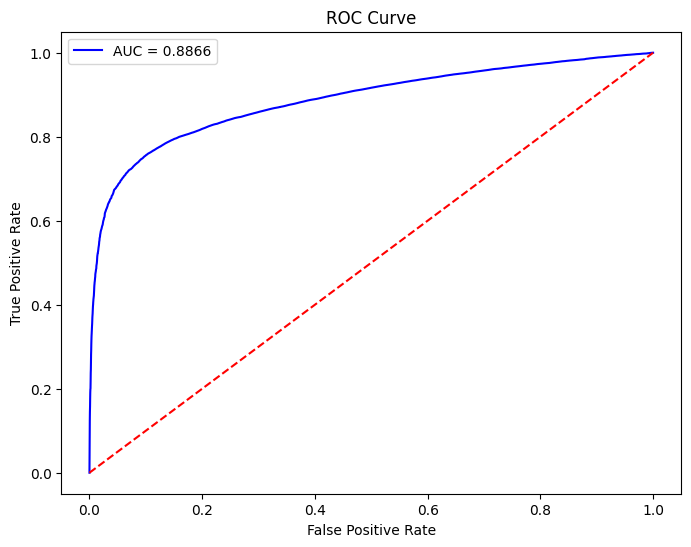

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], 'r--') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
